# Tutorial 3 — Final probabilistic forecasting qualitative analysis V3

This executed notebook is the primary V3 artifact. It uses **performance-aligned illustrative window selection** under fixed model seed 0 and fixed feature index 0. It is not a typical, random, representative, or unbiased window analysis. The all-window, three-seed FINAL_TEST table remains the primary quantitative evidence. No training or tuning occurs here.

In [1]:
from pathlib import Path
import json, sys
import numpy as np
import pandas as pd
from IPython.display import display, Image, Markdown, IFrame
ROOT=Path('/path/to/PETS-FFT-Ablation')
sys.path.insert(0,str(ROOT))
from scripts import run_probabilistic_forecasting_qualitative_v3 as v3
R=v3.V3_REPORTS
assert v3.SEED==0 and v3.FEATURE==0 and v3.TAU==1.5
print('FIXED: model seed=0; ETTh feature 0=HUFL; AirQuality feature 0=PT08.S1(CO)')
print('FINAL_TRAIN first 90%; FINAL_TEST last 10%; H=64 F=64 L=128; sampling steps=200')

FIXED: model seed=0; ETTh feature 0=HUFL; AirQuality feature 0=PT08.S1(CO)
FINAL_TRAIN first 90%; FINAL_TEST last 10%; H=64 F=64 L=128; sampling steps=200


/path/to/conda/envs/df/lib/python3.8/site-packages/tqdm/auto.py:22: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Inherited V2 scale/alignment audit

V3 reuses the audited V2 raw-row continuity and one-inverse-transform pipeline. V2 is preserved as the supplementary model-independent typical-window audit.

In [2]:
v2=json.loads((v3.V2_REPORTS/'final_audit_summary.json').read_text())
assert v2['status']=='COMPLETE'
needed={'ETTH_RAW_ROW_CONTINUITY_CONFIRMED','AIRQUALITY_RAW_ROW_CONTINUITY_CONFIRMED','SAME_RAW_SCALE_PER_DATASET_CONFIRMED'}
assert needed.issubset(set(v2['verdicts']))
print('V2_AUDITED_SCALE_ALIGNMENT_PIPELINE_CONFIRMED')
print('Main paper: performance-aligned illustrative windows')
print('Supplementary audit: V2 model-independent typical windows')

V2_AUDITED_SCALE_ALIGNMENT_PIPELINE_CONFIRMED
Main paper: performance-aligned illustrative windows
Supplementary audit: V2 model-independent typical windows


## Seed and feature freeze before scan

The immutable preselection record fixes seed 0, feature 0, official draw IDs, tau=1.5, central percentile bounds and the median-joint-gain rule before loading any per-window performance.

In [3]:
freeze=json.loads((R/'preselection_freeze.json').read_text())
assert freeze['model_seed']==0 and set(freeze['feature_index_by_dataset'].values())=={0}
assert freeze['one_hundred_arrays_loaded_before_freeze'] is False
display(pd.Series(freeze,name='frozen value').to_frame())

,frozen value
feature_index_by_dataset,"{'AirQuality': 0, 'ETTh': 0}"
feature_name_by_dataset,"{'AirQuality': 'PT08.S1(CO)', 'ETTh': 'HUFL'}"
ground_truth_percentile_bounds_inclusive,"[0.2, 0.8]"
marker,FINAL_PROBABILISTIC_QUALITATIVE_V3
model_seed,0
one_hundred_arrays_loaded_before_freeze,False
one_hundred_draw_ids,"[430000, 430001, 430002, 430003, 430004, 43000..."
selection_draw_ids,"[100000, 100001, 100002, 100003, 100004, 20000..."
selection_rule,eligible window closest to median eligible joi...
status,FROZEN_BEFORE_WINDOW_SCAN


## Official 10-draw selection ensemble and exact rule

For each FINAL_TEST window, `delta_mae = 100*(PETS_MAE-TS_MAE)/TS_MAE` and `delta_crps = 100*(PETS_CRPS-TS_CRPS)/TS_CRPS`. Eligibility requires both negative plus all four ground-truth percentiles in `[0.20,0.80]`. Then `joint_gain = 0.5*(-delta_mae)+0.5*(-delta_crps)`, and the eligible window closest to the eligible median is chosen, with lowest window index as tie-break. The 100 paths are never used for selection.

In [4]:
selection=pd.read_csv(R/'performance_aligned_window_selection.csv')
summary=pd.read_csv(R/'performance_aligned_window_summary.csv')
for dataset in v3.DATASETS:
    eligible=selection[(selection.dataset==dataset)&selection.eligible]
    chosen=selection[(selection.dataset==dataset)&selection.selected].iloc[0]
    median=eligible.joint_gain.median()
    assert np.isclose(abs(chosen.joint_gain-median),np.abs(eligible.joint_gain-median).min(),atol=1e-10)
    assert all(.2<=chosen[c]<=.8 for c in ['curvature_pct','variation_pct','range_pct','boundary_jump_pct'])
display(summary)

,dataset,total_windows,pets_improves_mae_count,pets_improves_crps_count,pets_improves_both_count,eligible_count,pets_improves_mae_fraction,pets_improves_crps_fraction,pets_improves_both_fraction,eligible_fraction,selected_window_index,selected_origin_row,selected_delta_mae,selected_delta_crps,selected_joint_gain,selected_curvature_pct,selected_variation_pct,selected_range_pct,selected_boundary_jump_pct,median_eligible_joint_gain
0,ETTh,1679,720,623,606,72,0.428827,0.371054,0.360929,0.042883,104,15782,-13.362904,-14.617606,13.990255,0.777844,0.488982,0.438952,0.519952,13.879457
1,AirQuality,872,379,379,354,65,0.434633,0.434633,0.405963,0.074541,272,8694,-26.321955,-18.273601,22.297778,0.637615,0.793578,0.704702,0.543578,22.297778


In [5]:
manifest=v3.selected_manifest()
selected=pd.DataFrame(manifest['selected_windows'])
assert manifest['status']=='WINDOWS_FROZEN_BEFORE_100_TRAJECTORY_RUN'
display(selected[['dataset','window_index','origin_row','feature_name','delta_mae','delta_crps','joint_gain','median_eligible_joint_gain']])
print('selection manifest SHA-256:',v3.q2.sha256(v3.manifest_path()))

,dataset,window_index,origin_row,feature_name,delta_mae,delta_crps,joint_gain,median_eligible_joint_gain
0,ETTh,104,15782,HUFL,-13.362904,-14.617606,13.990255,13.879457
1,AirQuality,272,8694,PT08.S1(CO),-26.321955,-18.273601,22.297778,22.297778


selection manifest SHA-256: f0a87256cc5a7a0b009db5794f1b265c07dcdbdd4d4990af06e4a6021c0f2fc3


In [6]:
ten=pd.read_csv(R/'displayed_window_metrics_10draw_selection.csv')
display(ten)
display(pd.read_csv(R/'aggregate_alignment_diagnostic.csv'))

,dataset,system,model_seed,window_index,origin_row,draws,ensemble_mean_mae,ensemble_mean_rmse,expected_sample_mae,empirical_crps
0,ETTh,TS_REC_ORIGINAL,0,104,15782,10,3.780373,5.775319,4.115248,3.175984
1,ETTh,PETS_SELECTED_CALIBRATED,0,104,15782,10,3.275206,4.600804,3.631648,2.711731
2,AirQuality,TS_REC_ORIGINAL,0,272,8694,10,216.766377,264.243910,228.406058,165.993083
3,AirQuality,PETS_SELECTED_CALIBRATED,0,272,8694,10,159.709228,202.373958,169.012105,135.660169


,dataset,aggregate_delta_mae,aggregate_delta_crps,selected_delta_mae,selected_delta_crps,euclidean_distance_percentage_points
0,ETTh,-3.125615,-3.070185,-13.362904,-14.617606,15.431948
1,AirQuality,-0.237659,-0.456144,-26.321955,-18.273601,31.588801


## Frozen-window 100-path provenance and calibration

Only after the manifest was frozen, exact labels 430000–430099 generated 100 TS and 100 raw PETS paths per dataset. Each metadata record binds the window-manifest and step-18000 checkpoint SHA-256 hashes. Predictions receive one FINAL_TRAIN inverse transform.

In [7]:
prov=pd.read_csv(R/'trajectory_provenance_100traj.csv')
assert len(prov)==4 and (prov.trajectories==100).all() and (prov.inverse_transform_count==1).all()
assert prov.window_frozen_before_generation.all() and (~prov.used_for_selection_or_reselection).all()
display(prov[['dataset','system','window_index','origin_row','trajectories','runtime_seconds','checkpoint_sha256','selection_manifest_sha256']])
mean_check=pd.read_csv(R/'pets_calibration_mean_preservation.csv')
assert mean_check.mean_preserved_below_1e_10.all()
display(mean_check)

,dataset,system,window_index,origin_row,trajectories,runtime_seconds,checkpoint_sha256,selection_manifest_sha256
0,ETTh,TS_REC_ORIGINAL,104,15782,100,13.322171,c6853ef3aa9d90cd8094284d79d44435d73b86d504c5b4...,f0a87256cc5a7a0b009db5794f1b265c07dcdbdd4d4990...
1,ETTh,PETS_SHTRAIN_CG64_REC,104,15782,100,22.201554,ee4c2ba77c8b246f6e6f058d55be6ca51ff99bcc29118f...,f0a87256cc5a7a0b009db5794f1b265c07dcdbdd4d4990...
2,AirQuality,TS_REC_ORIGINAL,272,8694,100,13.480320,676db36930cb679b5c30c0010bc214d8342e094661b13f...,f0a87256cc5a7a0b009db5794f1b265c07dcdbdd4d4990...
3,AirQuality,PETS_SHTRAIN_CG64_REC,272,8694,100,20.078674,bc911b5c0d0cccaeb33c753cea060f5e06b1917e7ea61b...,f0a87256cc5a7a0b009db5794f1b265c07dcdbdd4d4990...


,dataset,tau,max_abs_pointwise_mean_difference,mean_preserved_below_1e_10
0,ETTh,1.5,3.552714e-14,True
1,AirQuality,1.5,3.637979e-12,True


The displayed PETS paths use `mean = raw_pets.mean(axis=0, keepdims=True)` and `pets_cal = mean + 1.5*(raw_pets-mean)`. The ensemble mean is preserved below `1e-10`.

In [8]:
hundred=pd.read_csv(R/'displayed_window_metrics_100traj.csv')
ordering=pd.read_csv(R/'ten_vs_hundred_ordering.csv')
display(hundred)
display(ordering)
print('No window was reselected after observing these 100-path values.')

,dataset,system,model_seed,window_index,origin_row,feature_index,trajectories,ensemble_mean_mae,ensemble_mean_rmse,expected_sample_mae,empirical_crps
0,ETTh,TS_REC_ORIGINAL,0,104,15782,0,100,3.797889,5.802272,4.143470,3.105996
1,ETTh,PETS_SELECTED_CALIBRATED,0,104,15782,0,100,3.187362,4.404297,3.544307,2.510003
2,AirQuality,TS_REC_ORIGINAL,0,272,8694,0,100,197.712088,238.095543,225.658490,143.700882
3,AirQuality,PETS_SELECTED_CALIBRATED,0,272,8694,0,100,161.690432,204.466644,170.936134,133.446475


,dataset,trajectories,pets_lower_mae,pets_lower_crps,pets_lower_both,delta_mae_percent,delta_crps_percent
0,ETTh,10,True,True,True,-13.362904,-14.617606
1,ETTh,100,True,True,True,-16.075414,-19.188471
2,AirQuality,10,True,True,True,-26.321955,-18.273601
3,AirQuality,100,True,True,True,-18.219248,-7.135939


No window was reselected after observing these 100-path values.


## Main 2×2 qualitative probabilistic forecast figure

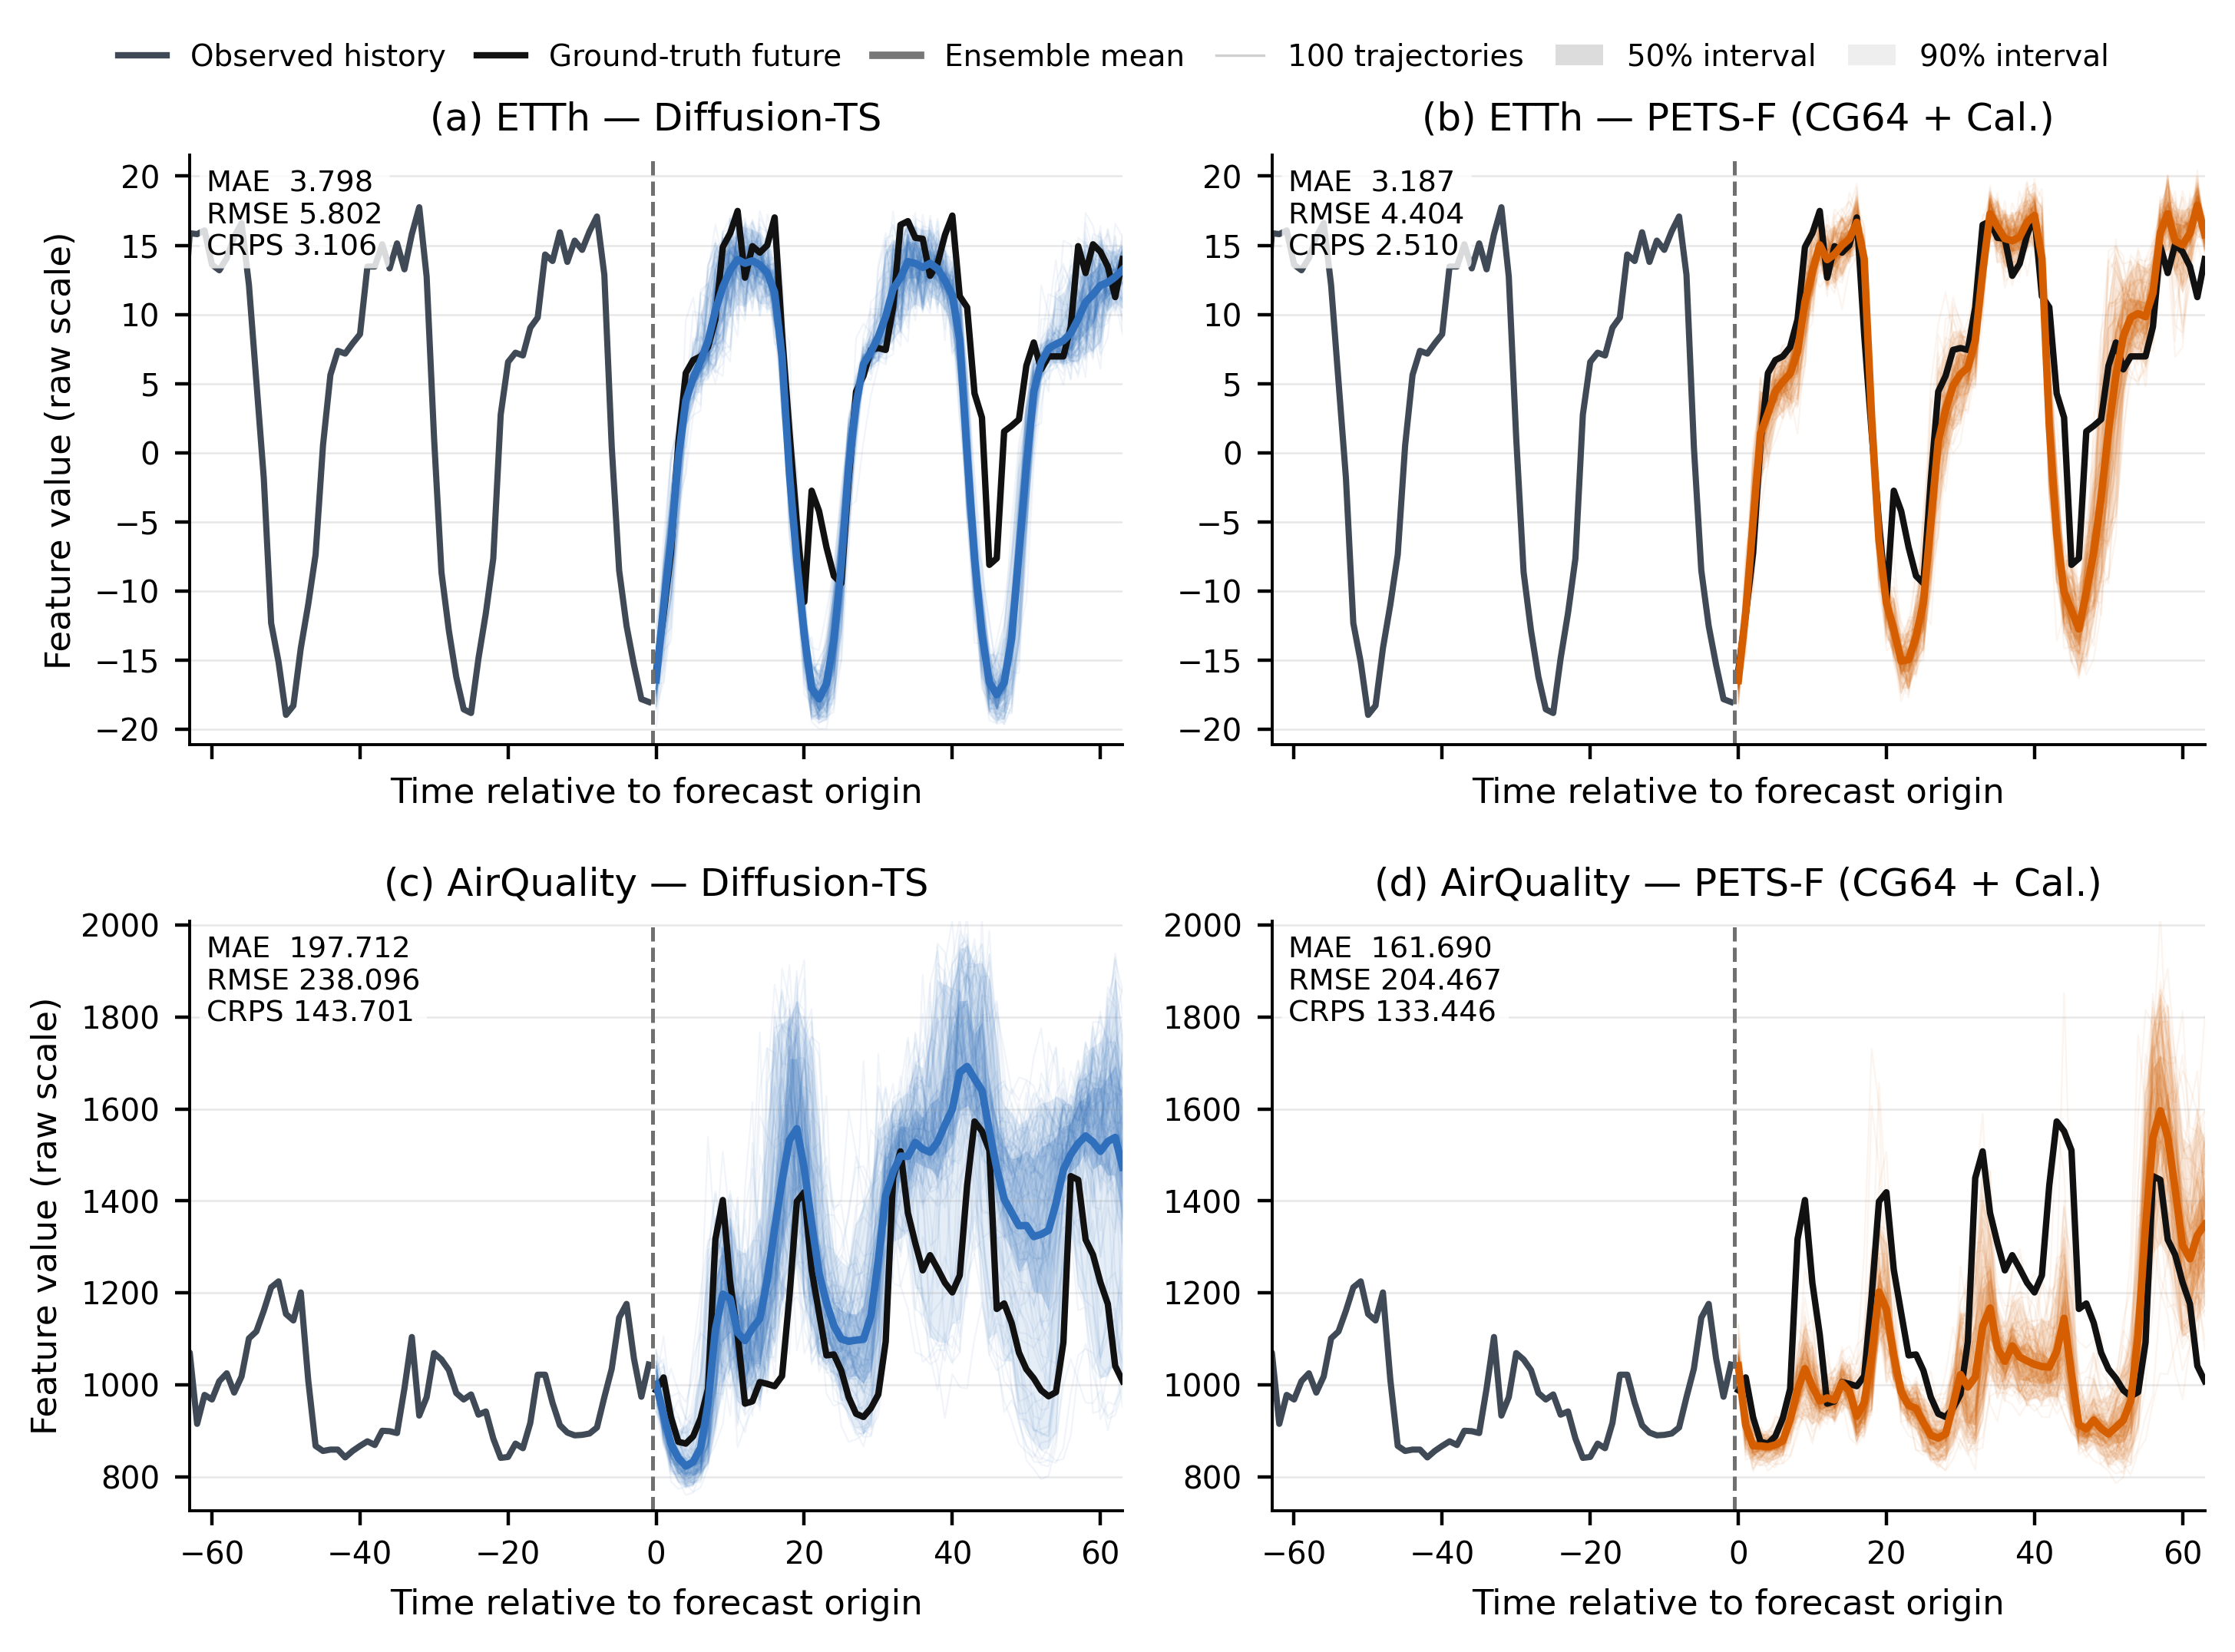

Shared y-limits by dataset: {'AirQuality': [726.1158309936524, 2008.255274963379], 'ETTh': [-21.104934949064255, 21.501521624708175]}


In [9]:
display(Image(filename=str(v3.FIGS/'probabilistic_forecasting_main_v3.png'),width=1050))
print('Shared y-limits by dataset:',json.loads((R/'shared_ylims_v3.json').read_text()))

## 100-trajectory shape comparison

Peak/trough timing and magnitude, phase-sensitive slope/curvature behavior, high-curvature error, derivative-sign agreement, turning points, spread and interval coverage are secondary diagnostics. They were not used for window selection.

In [10]:
shape=pd.read_csv(R/'shape_diagnostics_100traj.csv')
display(shape)
for dataset in v3.DATASETS:
    x=shape[shape.dataset==dataset].set_index('system')
    print(dataset,
          '| PETS/TS slope MAE',f"{x.loc['PETS_SELECTED_CALIBRATED','slope_mae']:.3g}/{x.loc['TS_REC_ORIGINAL','slope_mae']:.3g}",
          '| curvature MAE',f"{x.loc['PETS_SELECTED_CALIBRATED','curvature_mae']:.3g}/{x.loc['TS_REC_ORIGINAL','curvature_mae']:.3g}",
          '| turning F1',f"{x.loc['PETS_SELECTED_CALIBRATED','turning_point_f1_pm2']:.3f}/{x.loc['TS_REC_ORIGINAL','turning_point_f1_pm2']:.3f}")

,dataset,system,window_index,slope_mae,curvature_mae,high_curvature_mae,derivative_sign_agreement,turning_point_f1_pm2,truth_peak_step,mean_peak_step,...,trough_magnitude_abs_error,truth_mean_abs_curvature,ensemble_mean_abs_curvature,mean_over_truth_abs_curvature,individual_trajectory_mean_abs_curvature,individual_over_mean_abs_curvature,ensemble_mean_oversmooths_individual_trajectories,mean_ensemble_spread,coverage_50,coverage_90
0,ETTh,TS_REC_ORIGINAL,104,2.400056,3.509507,9.916002,0.698413,0.500000,11,11,...,2.051657,3.533952,1.242856,0.351690,2.929713,2.357242,True,1.873496,0.296875,0.625000
1,ETTh,PETS_SELECTED_CALIBRATED,104,2.262933,3.472379,9.095089,0.761905,0.787879,11,62,...,0.727534,3.533952,1.953540,0.552792,3.220444,1.648517,True,1.841739,0.234375,0.625000
2,AirQuality,TS_REC_ORIGINAL,272,70.720305,95.873578,280.121705,0.666667,0.685714,43,42,...,48.861685,93.403226,33.507282,0.358738,125.548102,3.746890,True,151.766366,0.156250,0.812500
3,AirQuality,PETS_SELECTED_CALIBRATED,272,69.762277,90.157911,273.425804,0.682540,0.714286,43,57,...,6.873552,93.403226,48.878510,0.523306,79.111289,1.618529,True,68.821735,0.171875,0.390625


ETTh | PETS/TS slope MAE 2.26/2.4 | curvature MAE 3.47/3.51 | turning F1 0.788/0.500
AirQuality | PETS/TS slope MAE 69.8/70.7 | curvature MAE 90.2/95.9 | turning F1 0.714/0.686


Both ensemble means are smoother than their individual trajectories, as expected from averaging. The table distinguishes this Monte-Carlo averaging effect from truth-relative curvature preservation and reports peak/trough timing and magnitudes directly.

## Ensemble-size convergence (deterministic prefixes)

In [11]:
conv=pd.read_csv(R/'ensemble_size_convergence_v3.csv')
display(conv)
display(IFrame(src=str(v3.FIGS/'probabilistic_forecasting_ensemble_size_convergence_v3.pdf'),width=900,height=360))

,dataset,system,M,ensemble_mean_mae,ensemble_mean_rmse,deterministic_prefix,draw_id_start,draw_id_end
0,ETTh,TS_REC_ORIGINAL,1,4.729215,6.852519,True,430000,430000
1,ETTh,TS_REC_ORIGINAL,5,3.928867,5.988612,True,430000,430004
2,ETTh,TS_REC_ORIGINAL,10,3.853602,5.883987,True,430000,430009
3,ETTh,TS_REC_ORIGINAL,20,3.902065,5.899390,True,430000,430019
4,ETTh,TS_REC_ORIGINAL,50,3.856182,5.863245,True,430000,430049
5,ETTh,TS_REC_ORIGINAL,100,3.797889,5.802272,True,430000,430099
6,ETTh,PETS_SELECTED_CALIBRATED,1,3.543365,4.783162,True,430000,430000
7,ETTh,PETS_SELECTED_CALIBRATED,5,3.496333,4.747508,True,430000,430004
8,ETTh,PETS_SELECTED_CALIBRATED,10,3.244917,4.478590,True,430000,430009
9,ETTh,PETS_SELECTED_CALIBRATED,20,3.155726,4.344195,True,430000,430019


## Raw versus calibrated PETS diagnostic

In [12]:
from IPython.display import IFrame
display(IFrame(src=str(v3.FIGS/'probabilistic_forecasting_pets_raw_vs_calibrated_v3.pdf'),width=900,height=360))

## Supplementary unbiased context

The V2 model-independent typical-window result remains untouched under `reports/histcond_cg64_final_forecast/qualitative_v2/`. Main-paper figure: performance-aligned illustrative windows. Supplementary audit: V2 model-independent typical windows.

## Disclosed paper caption

In [13]:
display(Markdown(v3.CAPTION))

Qualitative probabilistic forecasts on illustrative FINAL_TEST windows where the final PETS-F configuration yields lower ensemble-mean MAE and empirical CRPS than Diffusion-TS under a fixed seed-0 selection ensemble. To avoid extreme or best-case examples, candidate windows are restricted to the central 20--80% of ground-truth curvature, variability, amplitude range, and boundary-jump statistics, and the case closest to the median joint PETS improvement is shown. Thin curves denote 100 stochastic trajectories, the thick forecast curve their pointwise ensemble mean, and the shaded bands the 50% and 90% central prediction intervals. The quantitative FINAL_TEST comparison over all windows and three model seeds is reported separately in Table X.

## Final audit

In [14]:
audit=v3.verify()
assert audit['official_final_artifacts_unchanged']
assert not audit['model_training_performed'] and not audit['post_100_path_reselection_performed']
print('FINAL_PROBABILISTIC_QUALITATIVE_V3_COMPLETE')

SEED0_FIXED_BEFORE_WINDOW_SCAN
FEATURES_FIXED_BEFORE_WINDOW_SCAN
PERFORMANCE_ALIGNED_SELECTION_DISCLOSED
NO_BEST_CASE_EXTREME_SELECTION
GROUND_TRUTH_CENTRAL_20_80_FILTER_CONFIRMED
MEDIAN_JOINT_GAIN_SELECTION_CONFIRMED
WINDOW_FROZEN_BEFORE_100_TRAJECTORY_RUN
NO_RESELECTION_AFTER_100_TRAJECTORY_RUN
ONE_HUNDRED_TRAJECTORIES_CONFIRMED
SAME_WINDOW_PER_DATASET_CONFIRMED
SAME_TRUTH_PER_DATASET_CONFIRMED
SAME_RAW_SCALE_PER_DATASET_CONFIRMED
SAME_YLIM_PER_DATASET_CONFIRMED
FROZEN_TAU_1P5_ONLY_CONFIRMED
NO_OFFICIAL_FINAL_ARTIFACT_MUTATION
FINAL_PROBABILISTIC_QUALITATIVE_V3_COMPLETE
